## Iris Flower Classification Project

In [2]:
# Step 1: Load Important Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import os
import warnings
warnings.filterwarnings('ignore')
print('All modules are Loaded Successfully!!')

All modules are Loaded Successfully!!


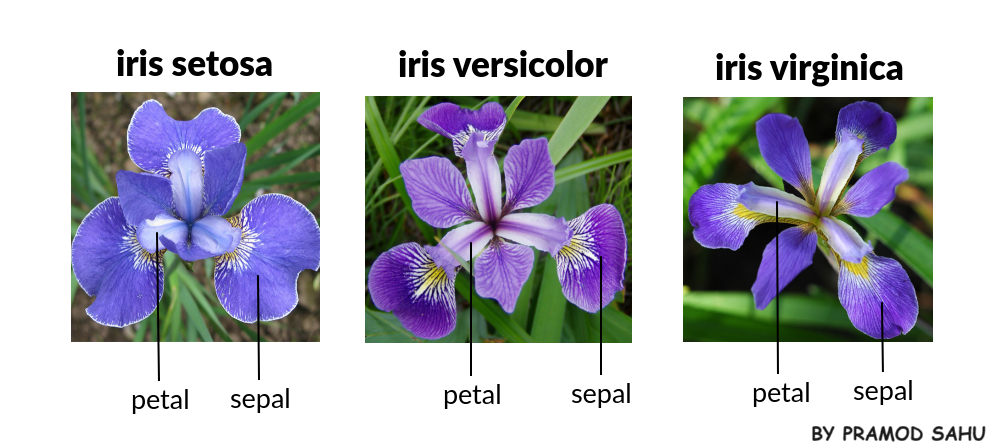

In [3]:
# Step 2: Load Dataset
from sklearn.datasets import load_iris
data= load_iris()
# Data object is in dict form
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [4]:
#  Load_iris inbuilt module to download the dataset
print(data['DESCR']) # Discription of data

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [5]:
# Step 3: Create Dataset
df= pd.DataFrame(data['data'], columns= data['feature_names'])
df['target']= data['target']
classes= data['target_names']
print(classes)
df.sample(3)

['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
21,5.1,3.7,1.5,0.4,0
138,6.0,3.0,4.8,1.8,2
145,6.7,3.0,5.2,2.3,2


In [6]:
# Step 4: EDA
df.shape

(150, 5)

In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [8]:
df.corr()   # to check corr between features vs target

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.000000,-0.117570,0.871754,0.817941,0.782561
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126,-0.426658
petal length (cm),0.871754,-0.428440,1.000000,0.962865,0.949035
petal width (cm),0.817941,-0.366126,0.962865,1.000000,0.956547
target,0.782561,-0.426658,0.949035,0.956547,1.000000


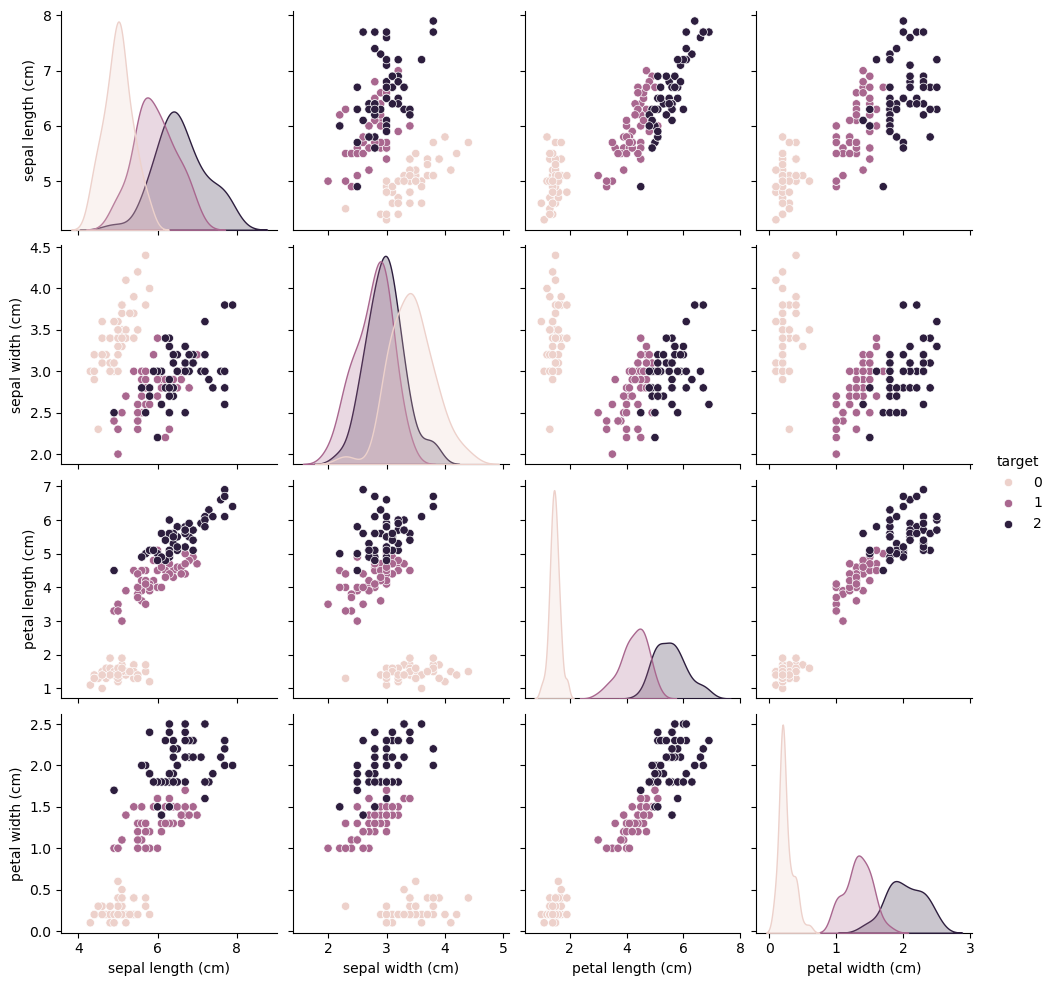

In [9]:
sns.pairplot(data= df, hue= 'target')
plt.show()

In [10]:
# Step 5: Target imbalance check
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [11]:
# Step 6: X and y
X= df.iloc[:,:-1]
y= df.iloc[:,-1]
print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [12]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

## Train Test Split Model

In [13]:
# Step 7: train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X ,y, test_size= 0.2, stratify= y, random_state= 42)

print('X_train_Shape:', X_train.shape)
print('X_test_Shape:', X_test.shape)
print('y_train_Shape:', y_train.shape)
print('y_test_Shape:', y_test.shape)

X_train_Shape: (120, 4)
X_test_Shape: (30, 4)
y_train_Shape: (120,)
y_test_Shape: (30,)


In [14]:
# Step 8: Different Model Building
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(X_train,y_train)

LogisticRegression()

In [15]:
# Logistic Model Training and Testing Score
lr_training_score= model_lr.score(X_train, y_train)
lr_testing_score= model_lr.score(X_test, y_test)
print('Training Score: ', lr_training_score)
print('Testing Score: ', lr_testing_score)

Training Score:  0.975
Testing Score:  0.9666666666666667


## Naive Bayes Model

In [16]:
# Model 2: Using Naive Bayes
from sklearn.naive_bayes import MultinomialNB
model_nv= MultinomialNB()
model_nv.fit(X_train, y_train)

MultinomialNB()

In [17]:
# Naive Bayes Model Training and Testing Score
nv_training_score= model_nv.score(X_train, y_train)
nv_testing_score= model_nv.score(X_test, y_test)
print('Training Score: ', nv_training_score)
print('Testing Score: ', nv_testing_score)

Training Score:  0.95
Testing Score:  1.0


## Decision Tree Model

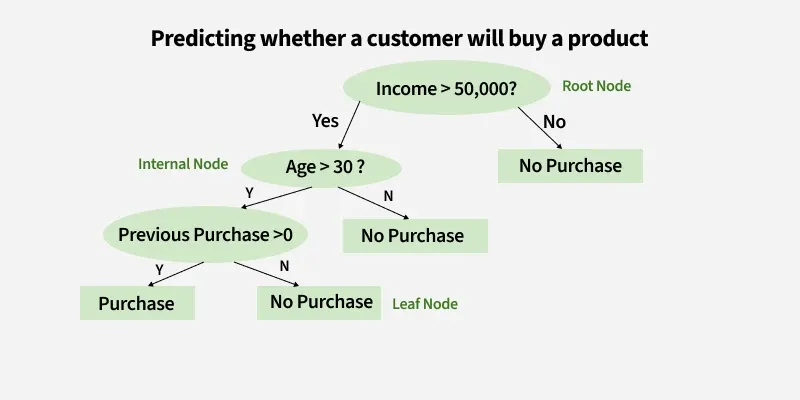

In [18]:
from sklearn.tree import DecisionTreeClassifier
#can be used in both Regression and Classification problems
model_dt= DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [19]:
#Decision Tree Model Training and Testing Score

dt_training_score= model_dt.score(X_train, y_train)
dt_testing_score= model_dt.score(X_test, y_test)
print('Testing Score:', dt_training_score)
print('Training Score:', dt_testing_score)

Testing Score: 1.0
Training Score: 0.9666666666666667


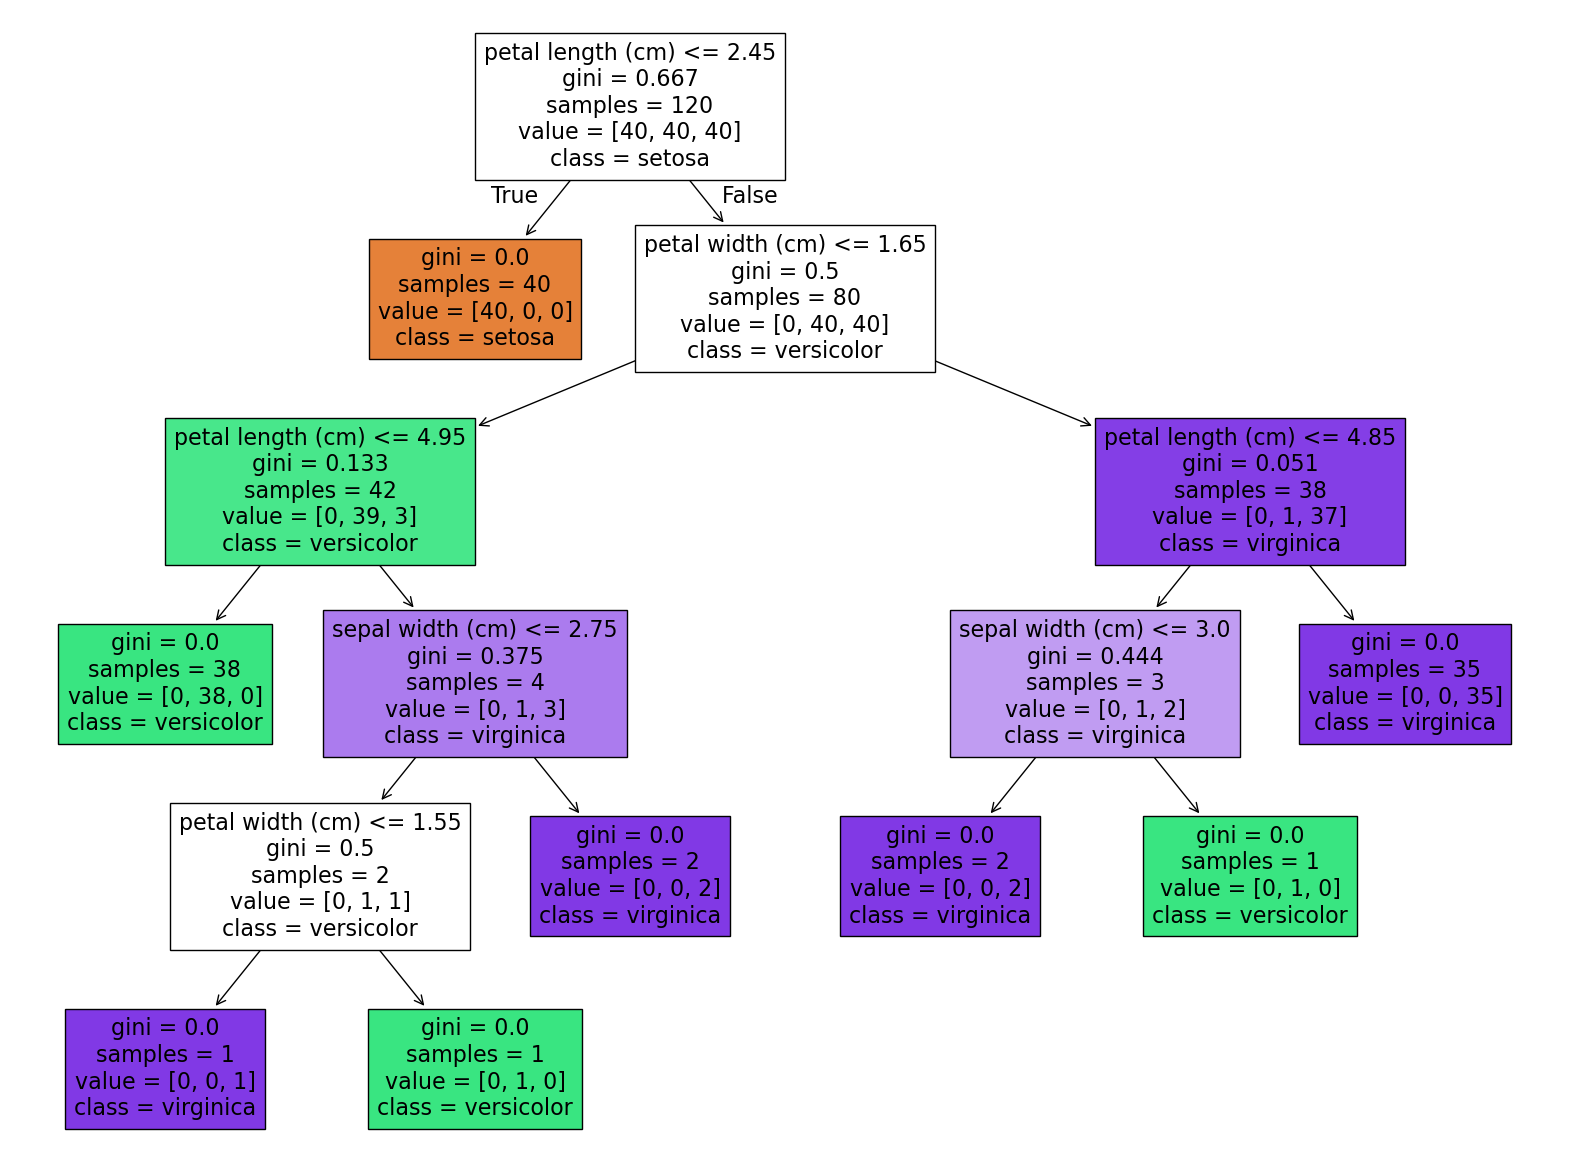

In [20]:
# Plot tree

from sklearn.tree import plot_tree
plt.figure(figsize= (20,15))
plot_tree(model_dt,
         feature_names= X.columns,
         filled=True,
         class_names= classes)
plt.show()

## Random Forest ML Model

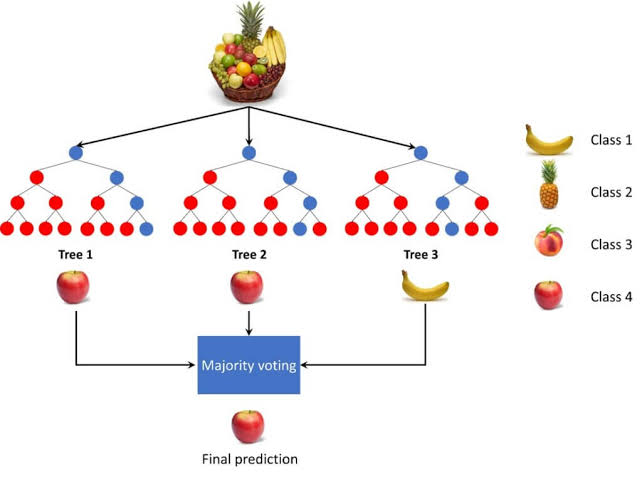

In [21]:
# Model 4: Model Training using Random Forest
from sklearn.ensemble import RandomForestClassifier
# Collection of multiple Trees ==> Random_Forest
model_rf= RandomForestClassifier(n_estimators= 100)  # 100: Trees
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [22]:
# Random Forest Model Training and Testing Score
rf_training_score= model_rf.score(X_train, y_train)
rf_testing_score= model_rf.score(X_test, y_test)
print('Testing Score:', rf_training_score)
print('Training Score:', rf_testing_score)

Testing Score: 1.0
Training Score: 0.9666666666666667


## SVM: Support Vector Machine

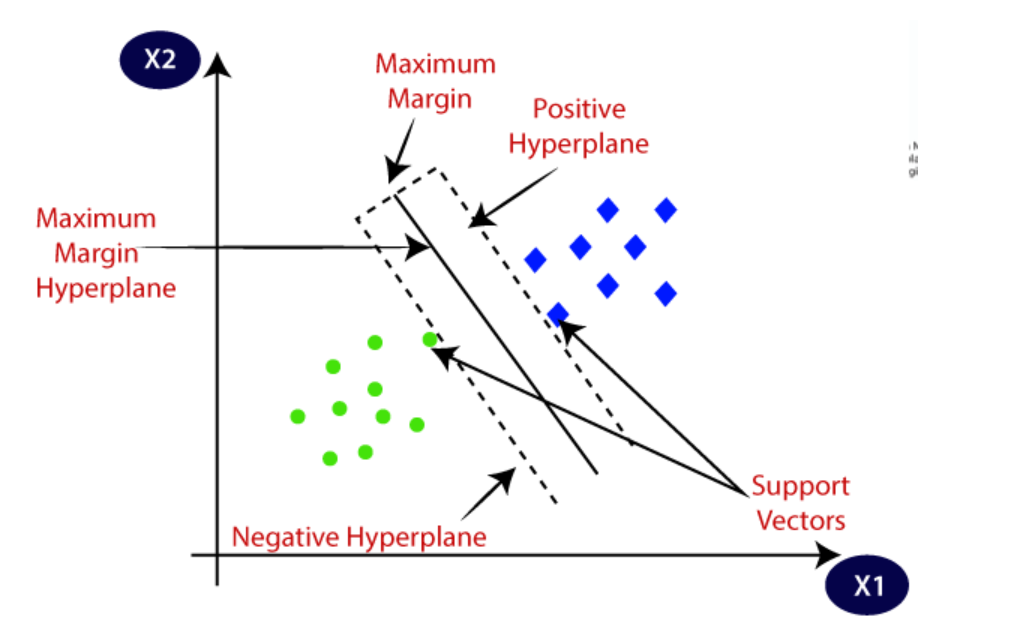

In [23]:
# Model 5 SVM: Support Vector Machine
from sklearn.svm import SVC
model_svm= SVC()
model_svm.fit(X_train, y_train)

SVC()

In [24]:
# SVM Model Training and Testing Score
svm_training_score= model_svm.score(X_train, y_train)
svm_testing_score= model_svm.score(X_test, y_test)
print('Testing Score:', svm_training_score)
print('Training Score:', svm_testing_score)

Testing Score: 0.9833333333333333
Training Score: 0.9666666666666667


## KNN: K-Nearest Neighbors

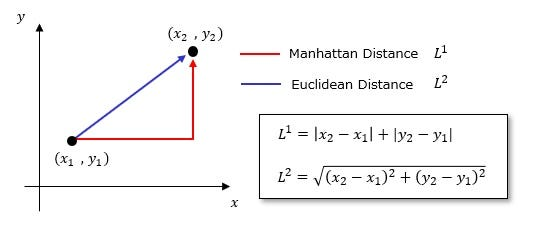

In [25]:
# Model 6: KNN: K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
model_knn= KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
# KNN Model Training and Testing Score
knn_training_score= model_knn.score(X_train, y_train)
knn_testing_score= model_knn.score(X_test, y_test)
print('Testing Score:', knn_training_score)
print('Training Score:', knn_testing_score)

Testing Score: 0.9666666666666667
Training Score: 1.0


In [27]:
# Comparision B/w All Models
all_model_name= ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'SVM', 'KNN']
all_models= [model_lr, model_nv, model_dt, model_rf, model_svm, model_knn]
all_y_pred= []
all_model_accuracy_score= []

count=0
for model in all_models:
    print(f"Checking Model==> {all_model_name[count]}")
    y_predicted= model.predict(X_test)
    acc_score= model.score(X_test, y_test)*100

    all_y_pred.append(y_predicted)
    all_model_accuracy_score.append(acc_score)

    print(f"Score: {acc_score}")
    count +=1
    print("==========\n\n")

Checking Model==> Logistic Regression
Score: 96.66666666666667


Checking Model==> Naive Bayes
Score: 100.0


Checking Model==> Decision Tree
Score: 96.66666666666667


Checking Model==> Random Forest
Score: 96.66666666666667


Checking Model==> SVM
Score: 96.66666666666667


Checking Model==> KNN
Score: 100.0




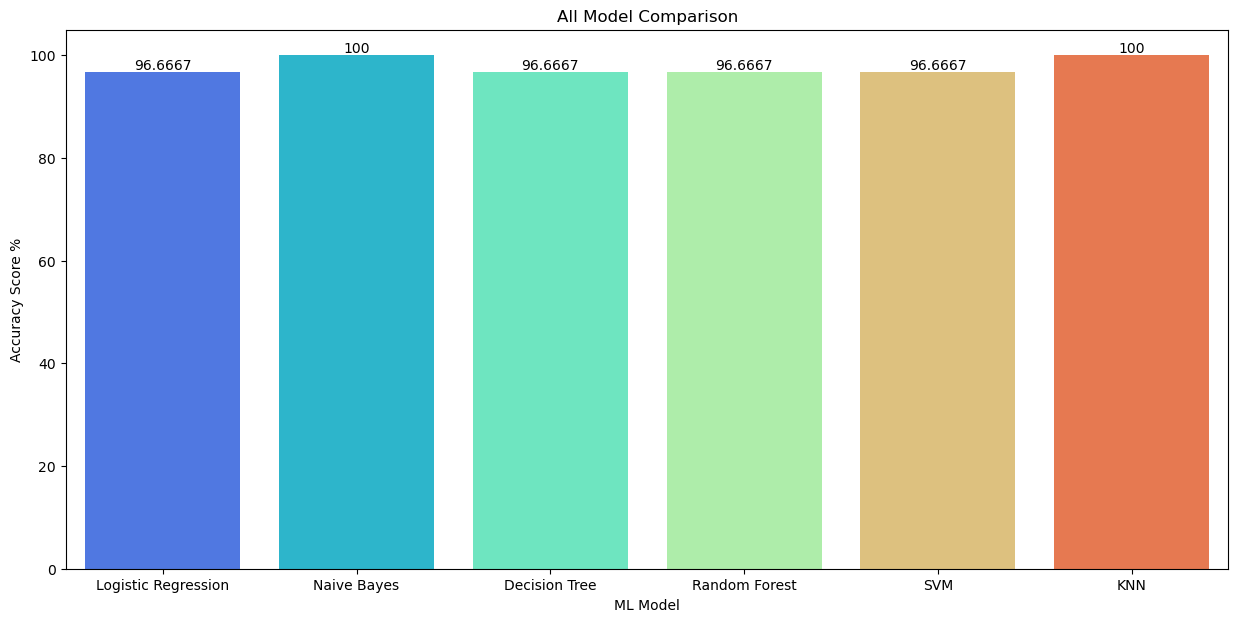

In [28]:
plt.figure(figsize= (15,7))
plt.title("All Model Comparison")
ax= sns.barplot(x= all_model_name, y= all_model_accuracy_score, palette= sns.color_palette('rainbow'))

for v in ax.containers:
    plt.bar_label(v)

plt.xlabel("ML Model")
plt.ylabel("Accuracy Score %")
plt.show()

# Since each model's score is above 90%, we can pick any model for the final
# Prediction, or Group Prediction

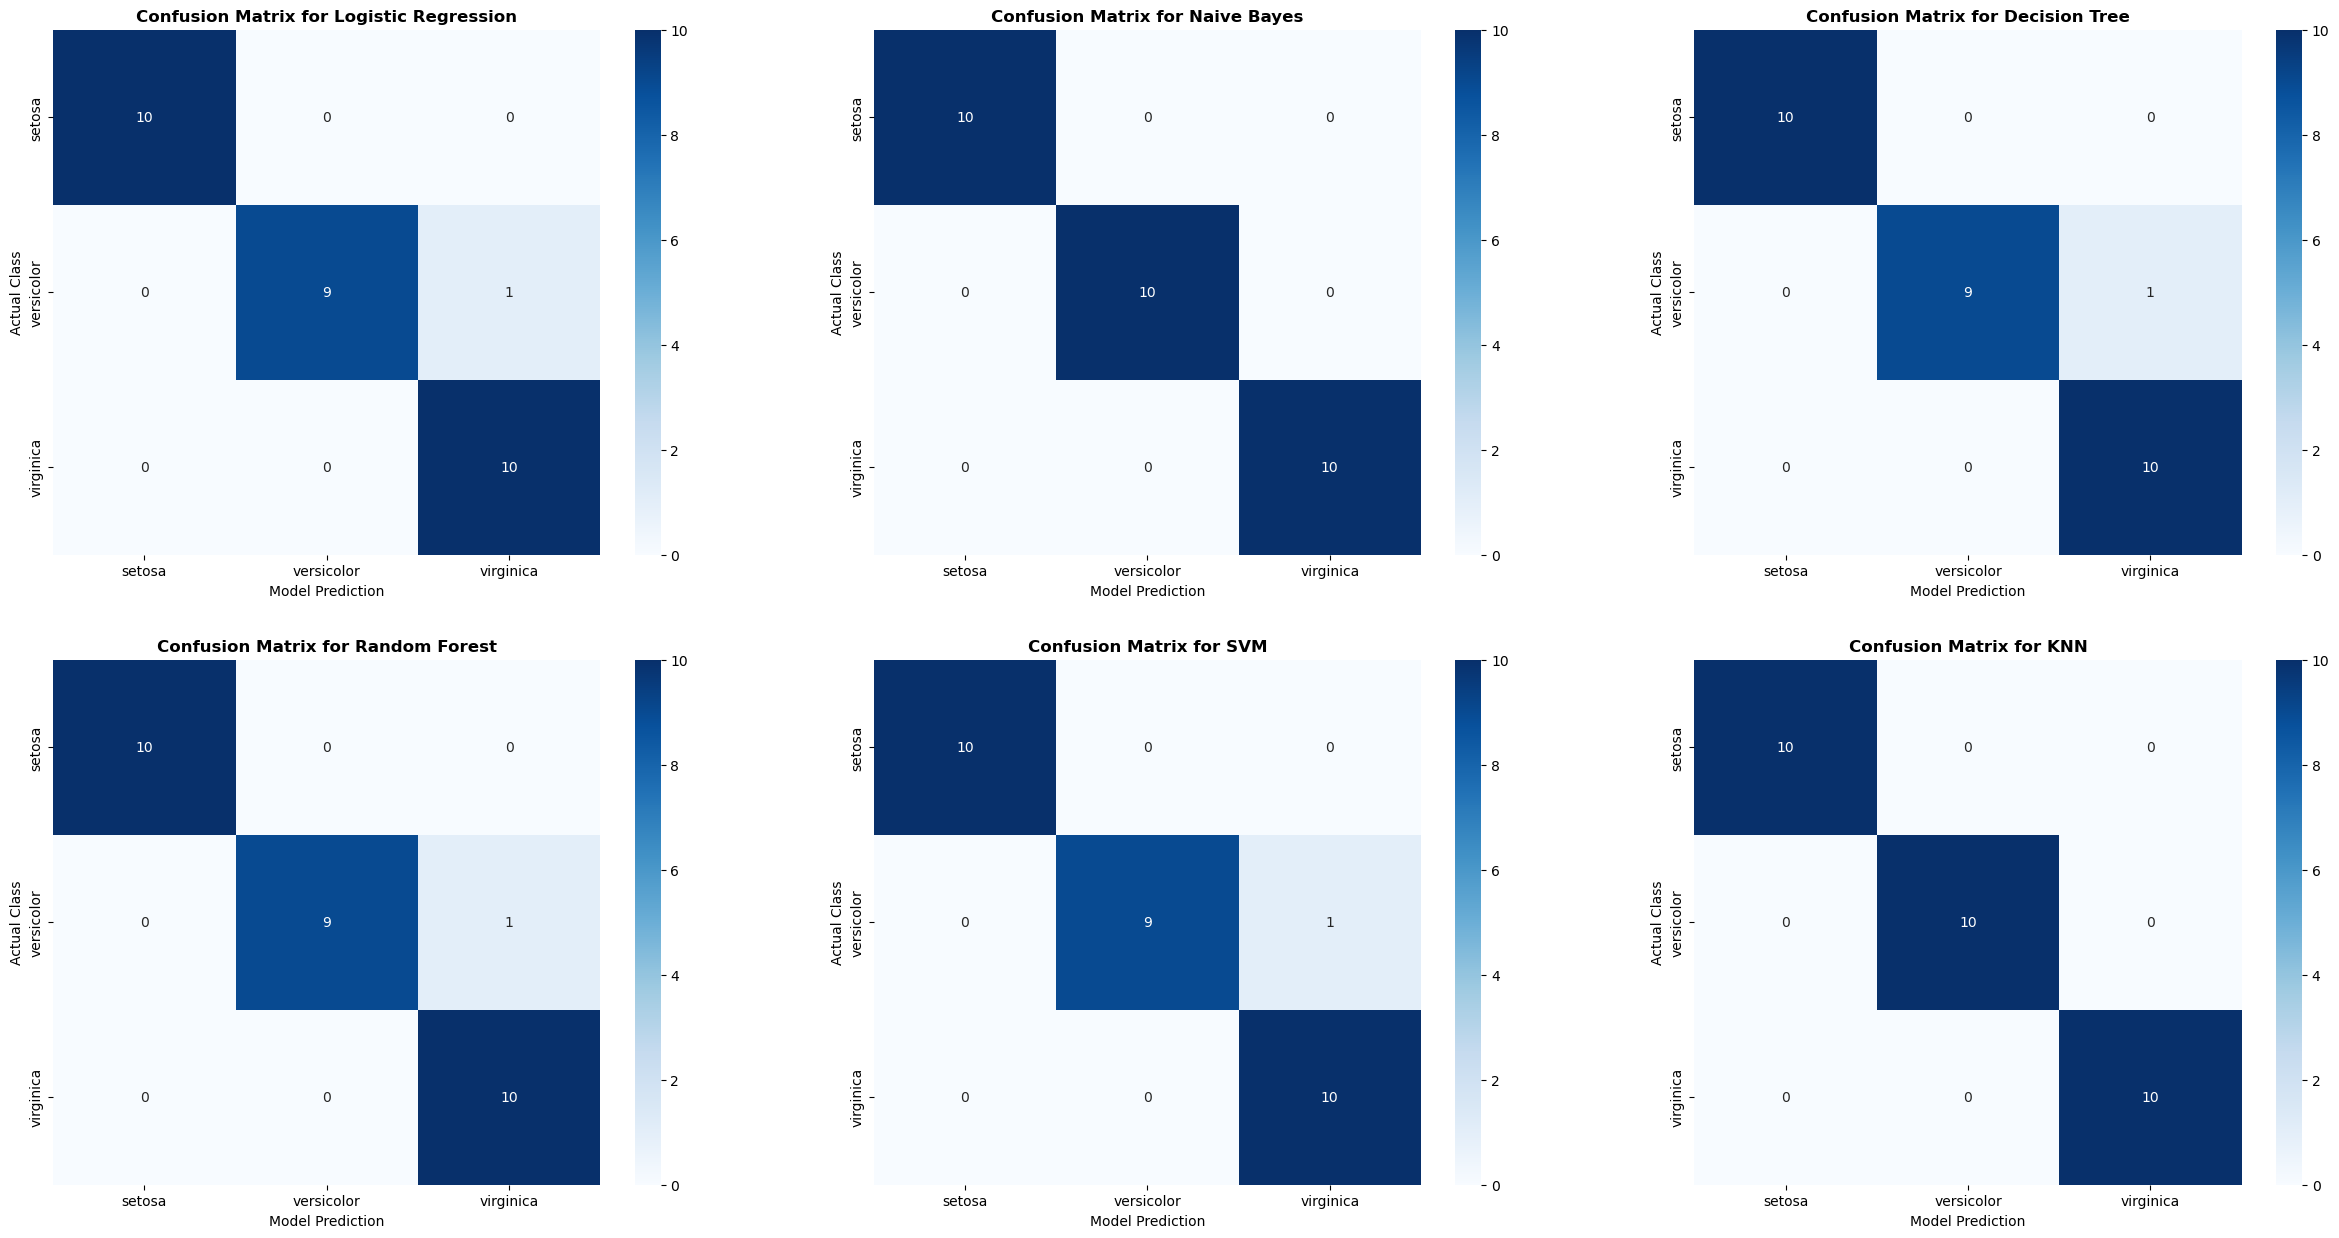

In [31]:
# All Model Confusion Matrix
from sklearn.metrics import confusion_matrix
plt.figure(figsize= (30,15))

for index, y_model in enumerate(all_y_pred):
    plt.subplot(2,3,index+1)
    plt.title(f"Confusion Matrix for {all_model_name[index]}", fontweight= "bold")
    cm= confusion_matrix(y_test, y_model)
    sns.heatmap(cm, annot=True, cmap= "Blues")
    plt.xlabel("Model Prediction")
    plt.ylabel("Actual Class")
    plt.xticks(np.linspace(0.5, 2.5, 3), classes)
    plt.yticks(np.linspace(0.5, 2.5, 3), classes)

plt.show()

In [32]:
# Save all Models
import pickle
#Pickle: To save objects so that other programming languages can use them
for index, model in enumerate(all_models):
    file_name= all_model_name[index]
    with open(f"{file_name}.pkl", 'wb') as f:
        pickle.dump(model,f)
    print(f"Mode: {file_name} Saved Successfully!!!!")

Mode: Logistic Regression Saved Successfully!!!!
Mode: Naive Bayes Saved Successfully!!!!
Mode: Decision Tree Saved Successfully!!!!
Mode: Random Forest Saved Successfully!!!!
Mode: SVM Saved Successfully!!!!
Mode: KNN Saved Successfully!!!!


In [33]:
# Create new file app.py
!pip install streamlit
# Streamlit: To create web based app